# CNN Image Classification with FruitinAmazon Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load and Visualize Sample Images

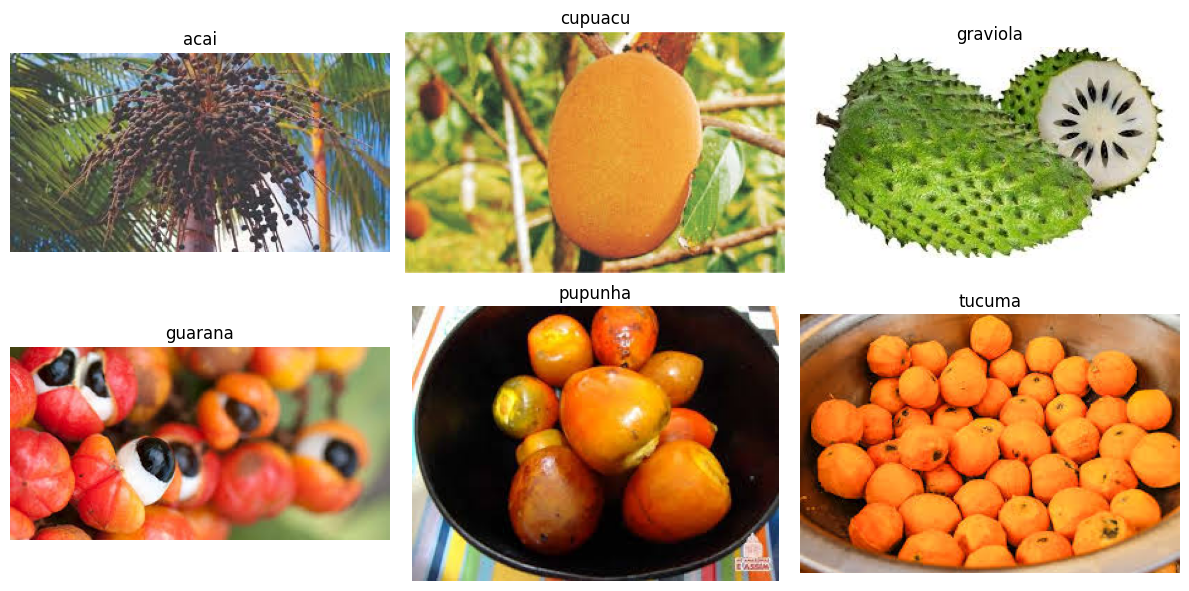

In [2]:
import os
import matplotlib.pyplot as plt
import random
from PIL import Image

train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/FruitinAmazon/test"
class_names = sorted(os.listdir(train_dir))

# Show sample images from each class
plt.figure(figsize=(12, 6))
for i, class_name in enumerate(class_names[:6]):
    class_path = os.path.join(train_dir, class_name)
    image_file = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, image_file))
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")
plt.tight_layout()
plt.show()


**Checking for Corrupted Image**

In [8]:
from PIL import UnidentifiedImageError
import os

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path)
            img.verify()  # Check for corruption
        except (UnidentifiedImageError, IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted_images:
    print("No corrupted images found.")


No corrupted images found.


## Load Training and Testing Data

In [3]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed=42
).map(lambda x, y: (rescale(x), y))

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    seed=42
).map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Found 30 files belonging to 6 classes.


## Build the CNN Model

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       8,388,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,408,902 (32.08 MB)

 Trainable params: 8,408,902 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train Model

In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=15, validation_data=test_ds)


Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.1392 - loss: 4.0370 - val_accuracy: 0.3000 - val_loss: 2.4086
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 943ms/step - accuracy: 0.3542 - loss: 2.1270 - val_accuracy: 0.3000 - val_loss: 1.7026
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3418 - loss: 1.6414 - val_accuracy: 0.4333 - val_loss: 1.4102
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5701 - loss: 1.2883 - val_accuracy: 0.4333 - val_loss: 1.2774
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.7043 - loss: 1.0151 - val_accuracy: 0.7333 - val_loss: 1.0409
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8665 - loss: 0.6846 - val_accuracy: 0.6667 - val_loss: 1.0325
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8497 - loss: 0.5438 - val_accuracy: 0.6667 - val_loss: 0.8590
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9371 - loss: 0.3615 - val_accuracy: 0.6333 - val_loss: 0.9762
Epoch 9/15
3

## Evaluate the Model

In [6]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {accuracy:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.7667 - loss: 0.9065
Test Accuracy: 0.7667


## Generate Classification Report

In [7]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

all_labels = list(range(len(class_names)))
print(classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.71      1.00      0.83         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.57      0.80      0.67         5
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.77        30
   macro avg       0.83      0.77      0.74        30
weighted avg       0.83      0.77      0.74        30

